# Заняття 10 — землетруси: лінійна регресія

In [1]:
%pip install -r requirements.txt -q


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Дані: розріз Землі під північним Чилі
> Кожен рядок — справжній землетрус: відстань від жолоба вглиб континенту, глибина і координати (широта, довгота). Тисячі поштовхів за 25 років.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("розріз-плити-пн.txt")
dist = data[:, 0]     # відстань від жолоба вглиб континенту, км
depth = data[:, 1]    # глибина, км
lat = data[:, 2]      # широта
lon = data[:, 3]      # довгота
print(len(dist))

2715


## Що ми досліджуємо
> Океанічна плита Наска впирається в континент і **пірнає під нього**, занурюючись у мантію. Поки тоне — тріскається, тож землетруси трапляються **вздовж усієї плити**: від жолоба біля берега до ~300 км углиб.
>
> **Гіпотеза:** якщо плита пірнає під сталим кутом, то що глибший землетрус — то далі він на схід. Глибина ∝ відстань → точки лягають на **пряму**, а її нахил = **кут занурення плити**.

## 1. Погляд зверху: мапа
> Намалюй землетруси на мапі (довгота-широта), колір = глибина. У який бік глибшає?

Text(0, 0.5, 'широта')

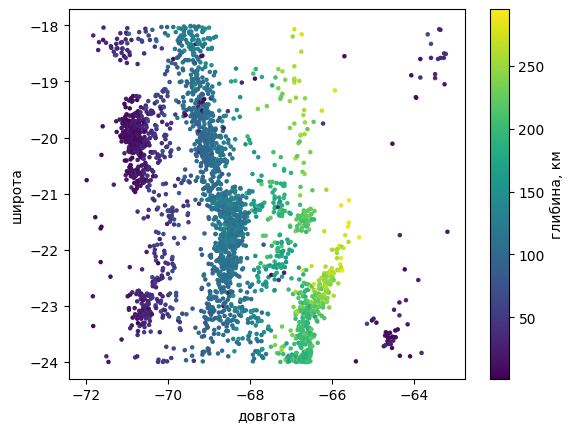

In [5]:
plt.scatter(lon, lat, c=depth, s=5)
plt.colorbar(label="глибина, км")
plt.xlabel("довгота")
plt.ylabel("широта")

### Та сама мапа, але справжня й інтерактивна (folium)
> Точки на реальній карті — можна зумити й перетягувати. Тут без кольору, просто щоб побачити географію.

In [10]:
import folium

m = folium.Map(location=[-21, -68], zoom_start=6)
for la, lo in zip(lat[::5], lon[::5]):
    folium.CircleMarker([la, lo], radius=2, color="red").add_to(m)
m.save("map_chile.html")
m

## 2. Збоку: розріз Землі
> «Повертаємо» картину вбік — дивимось на вертикальний зріз. По горизонталі — відстань від жолоба вглиб континенту, по вертикалі — глибина (вниз). Намалюй точки й познач поверхню та напрям, куди пірнає плита.

In [ ]:
plt.scatter(dist, depth, s=5, alpha=0.3)
plt.axhline(0, color="gray", lw=1)
plt.text(10, 15, "жолоб / узбережжя")
plt.annotate("плита пірнає в мантію",
             xy=(600, 180), xytext=(230, 70),
             arrowprops=dict(arrowstyle="->"))
plt.xlabel("відстань від жолоба вглиб континенту, км")
plt.ylabel("глибина, км")
plt.gca().invert_yaxis()

## 3. Проводимо пряму крізь хмару
> Точки розкидані — двома точками не обійдешся. `np.polyfit` сам знаходить НАЙКРАЩУ пряму `depth = k*dist + b` і повертає нахил `k` та зсув `b`.

In [ ]:
k, b = np.polyfit(dist, depth, 1)
print(k)
print(b)

### Малюємо цю пряму поверх точок

In [ ]:
plt.scatter(dist, depth, s=5, alpha=0.3)
x = np.array([dist.min(), dist.max()])
plt.plot(x, k * x + b, "r")
plt.xlabel("відстань від жолоба вглиб континенту, км")
plt.ylabel("глибина, км")
plt.gca().invert_yaxis()

## 4. Що означає нахил `k`
> `k` каже, на скільки кілометрів ГЛИБШЕ стає на кожен 1 км вглиб континенту.

In [ ]:
print(k * 100)

### Передбач сам: яка глибина буде за 300 км від жолоба?
> Підстав 300 у формулу `depth = k * 300 + b`.

## 5. Під яким кутом пірнає плита
> `np.arctan` перетворює нахил на кут, `np.degrees` — у градуси. Можна не знати, як рахує `arctan` — це «кнопка»: нахил → градуси.

In [ ]:
kut = np.degrees(np.arctan(k))
print(kut)

> Плита Наска пірнає під континент під кутом **~18°** — ми виміряли це просто з глибин землетрусів. Саме така похила смуга вогнищ (зона Вадаті-Беньйофа) колись і довела, що плити тонуть у мантію.

## 6. Застосуй сам: південніша смуга Чилі
> Файл `розріз-плити-пд.txt` — інша ділянка тієї ж плити. Завантаж його так само (перші дві колонки — відстань і глибина).

### Знайди для півдня нахил, намалюй пряму й обчисли кут
> Повтори кроки: `polyfit` → пряма поверх точок → `arctan`. Чи такий самий вийшов кут?

> На півдні плита пірнає **положе (~15°)**, ніж на півночі (~18°). Це не похибка: плита Наска реально вирівнюється південніше (Пампський «плоский слеб»). Проста пряма намацала справжню зміну форми плити.

## (*) Для допитливих
> 1. **Залишки.** Намалюй `depth - (k*dist + b)` від `dist`. Випадкові навколо нуля чи мають візерунок? (Візерунок → пряма не зовсім точна: справжній слеб трохи кривиться.)
> 2. **Екстраполяція.** Що дасть пряма за 1000 км? Чи реалістична така глибина?
> 3. **Лічба маскою.** Скільки землетрусів глибші за 150 км?